# Recommendation System Example

This notebook demonstrates the basics of a recommendation system using a user-item matrix
and calculates cosine similarity to show user similarity/dissimilarity.

In [ ]:
# Imports

import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd


---

# 1. Define the User-Item Matrix

Let's imagine 6 users rating 5 different items (e.g., movies, products).

Ratings
* 5: High rating
* 1: Low rating
* 0: Not rated or no preference

In [ ]:
# Each row contains one user's ratings
# Each column is the rating for a different movie (or product, etc.)
user_item_matrix = np.array([
    # Item 1, Item 2, Item 3, Item 4, Item 5
    [5, 4, 0, 0, 1],
    [4, 5, 0, 0, 2],
    [0, 0, 1, 3, 0],
    [0, 0, 5, 4, 0],
    [0, 0, 1, 3, 0],
    [0, 0, 5, 5, 0]
])

users = ['User 1', 'User 2', 'User 3', 'User 4', 'User 5', 'User 6']
items = ['Item A', 'Item B', 'Item C', 'Item D', 'Item E']

# Display the matrix using Pandas for better readability
df_user_item = pd.DataFrame(user_item_matrix, index=users, columns=items)

print("User-Item Matrix: \n")
print(df_user_item)


User-Item Matrix: 

        Item A  Item B  Item C  Item D  Item E
User 1       5       4       0       0       1
User 2       4       5       0       0       2
User 3       0       0       1       3       0
User 4       0       0       5       4       0
User 5       0       0       1       3       0
User 6       0       0       5       5       0


We can make some initial observations, but imagine 100,000s of users on 100,000s of products!


---

# 2. Calculate Cosine Similarity

**Cosine similarity** measures the cosine of the angle between two non-zero vectors.

* It ranges from -1 (opposite) to 1 (identical), with 0 indicating no similarity ("orthogonality").

* Two vectors that are identical would have a cosine similarity of 1.

* In recommendation systems, a higher cosine similarity indicates greater similarity between users or items.

There are other metrics besides cosine similarity that could be used.

## Illustration of cosine similarity

Cosine Similarity and Visualization Example

In [ ]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import norm

In [ ]:
# The definition of cosine similarity relies on the dot product and normalization (linear algebra topics)

# Function to compute cosine similarity
def my_cosine_similarity(a, b):
    return np.dot(a, b) / (norm(a) * norm(b))


Cosine similarity between v1 and v2: 1.00
Cosine similarity between v3 and v4: 0.00


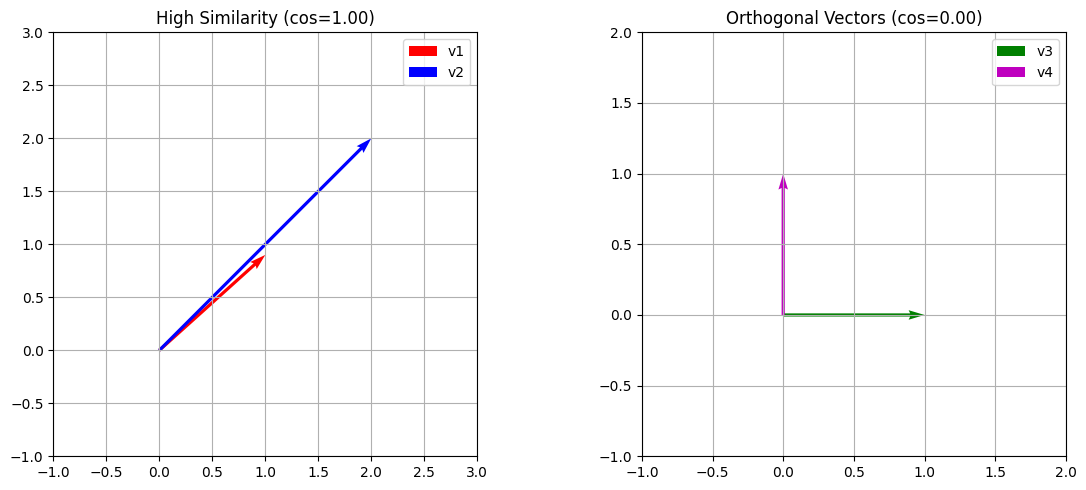

In [ ]:
# Define your vectors
v1 = np.array([1, 0.9])
v2 = np.array([2, 2])   # Small angle with v1 (high similarity)

v3 = np.array([1, 0])
v4 = np.array([0, 1])   # Orthogonal to v3 (cosine similarity = 0)

# Compute cosine similarities
sim1 = my_cosine_similarity(v1, v2)
sim2 = my_cosine_similarity(v3, v4)

print(f"Cosine similarity between v1 and v2: {sim1:.2f}")
print(f"Cosine similarity between v3 and v4: {sim2:.2f}")

# Plotting
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Plot v1 and v2
axs[0].quiver(0, 0, v1[0], v1[1], angles='xy', scale_units='xy', scale=1, color='r', label='v1')
axs[0].quiver(0, 0, v2[0], v2[1], angles='xy', scale_units='xy', scale=1, color='b', label='v2')
axs[0].set_title(f'High Similarity (cos={sim1:.2f})')
axs[0].set_xlim(-1, 3)
axs[0].set_ylim(-1, 3)
axs[0].grid(True)
axs[0].legend()
axs[0].set_aspect('equal')

# Plot v3 and v4
axs[1].quiver(0, 0, v3[0], v3[1], angles='xy', scale_units='xy', scale=1, color='g', label='v3')
axs[1].quiver(0, 0, v4[0], v4[1], angles='xy', scale_units='xy', scale=1, color='m', label='v4')
axs[1].set_title(f'Orthogonal Vectors (cos={sim2:.2f})')
axs[1].set_xlim(-1, 2)
axs[1].set_ylim(-1, 2)
axs[1].grid(True)
axs[1].legend()
axs[1].set_aspect('equal')

plt.tight_layout()
plt.show()


This visual is two dimensional, but we usually have many more dimensions (features) than that!

---

## Manual Recommendation System

In [ ]:
# Initialize empty matrix
num_users = user_item_matrix.shape[0]
user_similarity_matrix = np.zeros((num_users, num_users))

# Calculate similarity for all pairs
for i in range(num_users):
    for j in range(num_users):
        user_similarity_matrix[i, j] = my_cosine_similarity(user_item_matrix[i], user_item_matrix[j])

# Create a DataFrame for better readability
df_user_similarity = pd.DataFrame(user_similarity_matrix, index=users, columns=users)

print("User Similarity Matrix (Manual Cosine Similarity):\n")
print(df_user_similarity.round(2))

User Similarity Matrix (Manual Cosine Similarity):

        User 1  User 2  User 3  User 4  User 5  User 6
User 1    1.00    0.97    0.00    0.00    0.00    0.00
User 2    0.97    1.00    0.00    0.00    0.00    0.00
User 3    0.00    0.00    1.00    0.84    1.00    0.89
User 4    0.00    0.00    0.84    1.00    0.84    0.99
User 5    0.00    0.00    1.00    0.84    1.00    0.89
User 6    0.00    0.00    0.89    0.99    0.89    1.00


In [ ]:
# Using pre-built cosine_similarity
from sklearn.metrics.pairwise import cosine_similarity

# Calculate cosine similarity for all pairs of users using sklearn
user_similarity_matrix = cosine_similarity(user_item_matrix)

df_user_similarity = pd.DataFrame(user_similarity_matrix, index=users, columns=users)

print("User Similarity Matrix (Cosine Similarity):\n")

print(df_user_similarity.round(2))

User Similarity Matrix (Cosine Similarity):

        User 1  User 2  User 3  User 4  User 5  User 6
User 1    1.00    0.97    0.00    0.00    0.00    0.00
User 2    0.97    1.00    0.00    0.00    0.00    0.00
User 3    0.00    0.00    1.00    0.84    1.00    0.89
User 4    0.00    0.00    0.84    1.00    0.84    0.99
User 5    0.00    0.00    1.00    0.84    1.00    0.89
User 6    0.00    0.00    0.89    0.99    0.89    1.00


# 3. Analyze specific user similarity

In many contexts, a common threshold for 'high' similarity is when cosine similarity is at least 0.70

## User 1 vs. User 2

In [ ]:
# User 1 vs User 2
print(user_item_matrix[0:2, 0:5])

similarity_1_2 = user_similarity_matrix[0, 1] # Index 0 for User 1, Index 1 for User 2

print(f"Similarity between User 1 and User 2: {similarity_1_2:.2f}")

[[5 4 0 0 1]
 [4 5 0 0 2]]
Similarity between User 1 and User 2: 0.97


## User 3 vs. User 5

In [ ]:
# User 3 vs User 5
print(user_item_matrix[(2, 4), 0:5])

similarity_3_5 = user_similarity_matrix[2, 4] # Index 2 for User 3, Index 4 for User 5

print(f"Similarity between User 3 and User 5: {similarity_3_5:.2f}")

[[0 0 1 3 0]
 [0 0 1 3 0]]
Similarity between User 3 and User 5: 1.00


User 3 rates Pumpkin Spice Lattes and Pumpkin Spice cold brews from 1-5. User 5 has the same ratings, so it's a perfect similarity of 1.

## User 1 vs. User 6

In [ ]:
# User 1 vs User 6
print(user_item_matrix[(0, 5), 0:5])



similarity_1_6 = user_similarity_matrix[0, 5] # Index 0 for User 1, Index 5 for User 6

print(f"Similarity between User 1 and User 6: {similarity_1_6:.2f}")

[[5 4 0 0 1]
 [0 0 5 5 0]]
Similarity between User 1 and User 6: 0.00


---

For more information on recommendation systems in Python, see
* [Kaggle](https://www.kaggle.com/code/gspmoreira/recommender-systems-in-python-101)
* [Geeks for Geeks](https://www.geeksforgeeks.org/recommendation-system-in-python/)
* [Data Camp](https://www.datacamp.com/tutorial/recommender-systems-python)

For more information on the mathematics behind recommendation systems, see
* [RecSys](https://nafeea3000.medium.com/recommender-systems-c8db209dd0d3)
* [The Math of RecSys](https://levelup.gitconnected.com/the-mathematics-of-recommendation-systems-e8922a50bdea)